# Metalens Surrogate

**Note: the cost of running the entire notebook is higher than 4 FlexCredits. It also requires at least tidy3d version 2.8 to run.**

In this notebook, we aim to design and simulate a metasurface lens (metalens) by using a neural network to learn the mapping between unit cell geometry and the transmission amplitude and phase. For a more general introduction to metalenses from a conceptual and design perspective, please refer the the [Metalens](Metalens.ipynb) and [MidIRMetalens](MidIRMetalens.ipynb) notebooks. Metasurface design often consists of (1) finding a general unit cell defined by one or more geometric properties like, for example, a cylindrical post with a variable radius, (2) sweeping the geometric parameters and simulating the unit cell with periodic boundary conditions to characterize the phase and amplitude of the transfer function of the unit cell (thus creating what is often referred to as a unit cell or post library), and (3) tiling the unit cells in an array according to the desired phase/amplitude function of the optic.

We explore here a variation on this design flow that demonstrates the ease at which we can use tidy3d simulation output data as a source for training neural network models. Using the design plugin, we generate a random sampling of metasurface unit cells and run simulations to characterize their transfer functions. Based on this data, we train a neural network to learn the mapping between the unit cell geometric parameters and the amplitude and phase of the transfer function. We refer to this neural network as a surrogate model because we use it to take the place of running full electromagnetic simulations of candidate unit cells. For the final step, we utilize the surrogate solver to build a lookup table where we can choose an appropriate post radius based on a desired phase. These posts are tiled according to a focusing profile to create the final metalens. The full metalens is run through a tidy3d simulation where we take advantage of tidy3d's ability to quickly solve large scale electromagnetic problems. Using this simulation result, we measure the expected focusing performance of the lens and see places where it deviates from ideal behavior.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import xarray

import tidy3d as td
import tidy3d.web as web
import tidy3d.plugins.design as tdd

In [2]:
# configure notebook options for re-using simulation data if it exists
use_previous_simulation_data = False

# a directory for storing the Monte Carlo unit cell data
output_dir = Path("./misc/metalens_surrogate/")
mc_data_dir = output_dir / "data"

mc_data_dir.mkdir(parents=True, exist_ok=True)

In [3]:
#
# Geometric/Simulation parameters
#
lda0 = 10.6  # operation wavelength
freq0 = td.C_0 / lda0  # operation frequency
ldas = np.linspace(10.1, 11.1, 101)  # operation wavelength
freqs = td.C_0 / ldas

P = 6.2  # period of the unit cell
h = 6.8  # height of the pillar

inf_eff = 1e5  # effective infinity

major_radius_span = (0.75, 1.8)
minor_radius_span = (0.75, 1.8)
angle_deg_span = (0, 180)

sim_run_time = 3e-11

#
# Material parameters (we choose materials here that are suitable for the mid-infrared)
#
n_si = 3.43  # refractive index of silicon
n_caf2 = 1.3  # utilize a low refractive index, transparent CaF2 substrate in this section of the mid-infrared
si = td.Medium(permittivity=n_si**2)
caf2 = td.Medium(permittivity=n_caf2**2)

#
# Optimization parameters
#
num_monte_carlo_sims = 100
num_phi_optimization_points = 100

filename_mc_data = mc_data_dir / f"result_{num_monte_carlo_sims}.pkl"
if not filename_mc_data.exists() and use_previous_simulation_data:
    print(
        "Warning, MC simulation data does not exist to be loaded. Reconfiguring use_previous_simulation_data flag to False and recomputing."
    )
    use_previous_simulation_data = False

Here, we create a function to generate arbitrary silicon elliptical posts in tidy3d. These are based on sampling points around the border of an ellipse and then generating a `PolySlab` from those points. The post is defined by the `major_radius`, `minor_radius`, and the `angle_deg` it is rotated in the xy plane. It is extruded in the z-direction.

In [4]:
def create_ellipse(major_radius, minor_radius, angle_deg, x_offset, y_offset):
    def generate_ellipse_points(
        major_radius, minor_radius, x_offset, y_offset, num_points=100
    ):
        """
        Generate points along the boundary of an ellipse.

        Parameters:
        - major_radius (float): The length of the semi-major axis (major radius).
        - minor_radius (float): The length of the semi-minor axis (minor radius).
        - num_points (int): The number of points to generate (default is 100).

        Returns:
        - numpy.ndarray: An array of shape (num_points, 2) containing the (x, y) coordinates of the ellipse.
        """
        t = np.linspace(
            0, 2 * np.pi, num_points, endpoint=False
        )  # avoid duplicate points at 0=2pi

        # Parametric equations for the ellipse
        x = major_radius * np.cos(t)
        y = minor_radius * np.sin(t)

        # Combine x and y into a single array
        points = np.column_stack((x, y))

        return points

    angle_rad = np.deg2rad(angle_deg)  # define angle in radians for `cos` and `sin`
    vertices = generate_ellipse_points(major_radius, minor_radius, x_offset, y_offset)
    rot_mat = [
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)],
    ]
    vertices_rotated = vertices.dot(rot_mat)

    # Add offset
    vertices_rotated[:, 0] = vertices_rotated[:, 0] + x_offset
    vertices_rotated[:, 1] = vertices_rotated[:, 1] + y_offset

    ellipse = td.Structure(
        geometry=td.PolySlab(vertices=vertices_rotated, axis=2, slab_bounds=(0, h)),
        medium=si,
    )

    return ellipse


def make_sim(major_radius, minor_radius, angle):
    """Make simulation for characterizing the transfer function a metasurface unit cell.
    A plane wave is input into the device and is absorbed in the z-direction by PML boundary
    conditions. In the lateral (x,y) dimensions, we assume the unit cell looks at least
    locally periodic and thus we use periodic boundary conditions."""

    # Define geometry
    substrate_geo = td.Box.from_bounds(
        rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, 0)
    )
    substrate = td.Structure(geometry=substrate_geo, medium=caf2, name="substrate")

    # Define ellipse
    ellipse = create_ellipse(major_radius, minor_radius, angle, 0, 0)

    # Add a plane wave source - defaults to x-polarization for plane wave propagating in z
    plane_wave1 = td.PlaneWave(
        source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
        size=(td.inf, td.inf, 0),
        center=(0, 0, -0.1 * lda0),
        direction="+",
    )

    # Define a diffraction monitor to calculate the transmission coefficient
    monitor_t = td.DiffractionMonitor(
        center=[0, 0, h + 0.5 * lda0], size=[td.inf, td.inf, 0], freqs=freqs, name="t"
    )

    # Define boundary conditions
    boundary_spec = td.BoundarySpec(
        x=td.Boundary.periodic(),
        y=td.Boundary.periodic(),
        z=td.Boundary(minus=td.PML(), plus=td.PML()),
    )

    Lz = h + 1.2 * lda0  # simulation domain size in z direction
    min_steps_per_wvl = 12  # minimum steps per wavelength for the grid

    # Define a function to create unit cell simulation given pillar diameter
    sim = td.Simulation(
        center=(0, 0, h / 2),
        size=(P, P, Lz),
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=min_steps_per_wvl, wavelength=lda0
        ),
        structures=[ellipse, substrate],
        sources=[plane_wave1],
        monitors=[monitor_t],
        run_time=sim_run_time,
        boundary_spec=boundary_spec,  # pml is applied to z direction. x and y directions are periodic
    )

    return sim

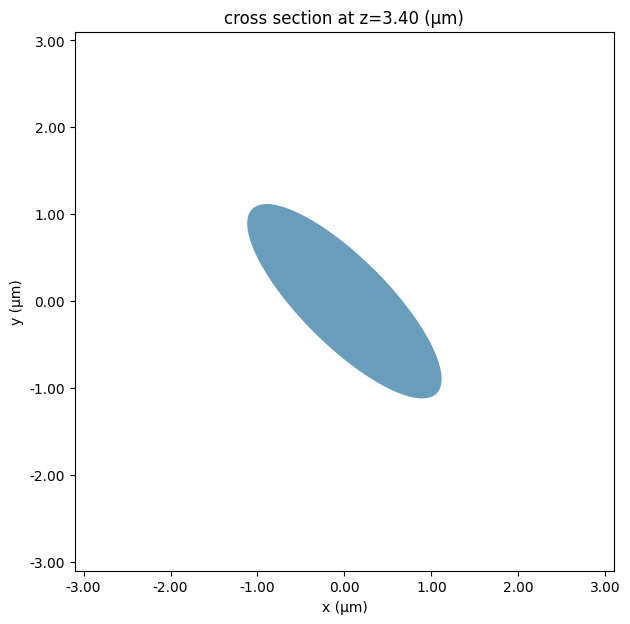

In [5]:
# Test the simulation creation and plot the cross section of the unit cell
sim = make_sim(major_radius=1.5, minor_radius=0.5, angle=45)
fig, ax = plt.subplots(figsize=(7, 7))
sim.plot(z=h / 2, ax=ax)
plt.show()

First, we use the tidy3d design plugin to randomly sample unit cell geometric parameters and simulate the resulting transfer functions. Through the plugin, we can create a `DesignSpace` built around a set of relevant parameters. We specify a method for how to explore these parameters. In this case, we would like to draw random combinations of the parameters for which we use the `MethodMonteCarlo` class. Finally, we define a function to run after each set of parameters is simulated. `fn_postprocess_unit_cell_simulation` collects the complex transmission coefficient through the unit cell which is saved in the design space result.

In [6]:
# Setup a Monte Carlo method that draws num_monte_carlo_sims random samples from the parameters
monte_carlo = tdd.MethodMonteCarlo(
    num_points=num_monte_carlo_sims,
    seed=1,
)

maj_r = tdd.ParameterFloat(name="major_radius", span=major_radius_span)
min_r = tdd.ParameterFloat(name="minor_radius", span=minor_radius_span)
ang = tdd.ParameterFloat(name="angle", span=angle_deg_span)
parameters = [maj_r, min_r, ang]

design_space = tdd.DesignSpace(
    method=monte_carlo,
    parameters=parameters,
    task_name="Metalens_MC_Surrogate",
    path_dir=str(mc_data_dir),
)


# This will be run to extract the complex transmission coefficient after the unit cell is simulated.
def fn_postprocess_unit_cell_simulation(sim_data):
    t = sim_data["t"]
    return {"t": t}

Here, we run the Monte Carlo simulations or load previous simulation data from a past run thruogh the notebook. If the simulations are run again, we overwrite the simulation data file to be loaded again in the future. By setting the `use_previous_simulation_data` flag, you can opt to use past data or rerun the simulations. If any of the parameters controlling the general geometry or number of simulations are changed, you should rerun the simulations to ensure they are accurate for the result of the notebook.

In [7]:
if use_previous_simulation_data:
    with open(filename_mc_data, "rb") as in_file:
        results = pickle.load(in_file)
        df = results.to_dataframe()
else:
    results = design_space.run(
        make_sim, fn_postprocess_unit_cell_simulation, verbose=True
    )
    df = results.to_dataframe()

    with open(filename_mc_data, "wb") as out_file:
        pickle.dump(results, out_file)

20:29:29 CST Running 100 Simulations

## Create surrogate neural network model

Using the Monte Carlo data, we will optimize a neural network to act as a surrogate for the electromagnetic solver. We will use it to learn the mappping between the major radius, minor radius, and rotation angle of the post along with the input frequency to the real and imaginary parts of the output field. We are simplifying the transmission coefficient by considering just the transmission in the p-polarized component. This corresponds to the same polarization as the input plane wave. Elliptical posts are birefringent and depending on their angular orientation and input polarization can act as waveplates and convert polarization. This is a useful design dimension in a metasurface library because it allows independent transfer functions to be selected for two independent input polarizations. However, in our case, we will ultimately be interested in a polarization independent design. To address this, we later simplify to searching through  circular post cross sections that do not exhibit any birefringence. However, in this first part where the neural network learns based on rotated ellipse shapes, the polarization rotation will effectively show up as loss in transmission since we are only learning the p-polarized to p-polarized transfer function. An interesting extension of this neural network surrogate would be to learn the 2x2 Jones matrix corresponding to the unit cell. This matrix describes the full transfer function for arbitrary input polarization including polarization conversion effects.

After running the Monte Carlo search, we first visualize the transfer functions from all of the randomly selected unit cells. In a transmissive metasurface library, we ideally have access to posts that span [0, 2$\pi$] phase with high transmission. Ensuring we have evidence of this phase coverage is important before moving onto the next step of the optimization. After visualization, we create a dataset we can feed into neural network training that we repackage into the `Result` class from the design plugin. We can directly use this as a pytorch dataset.

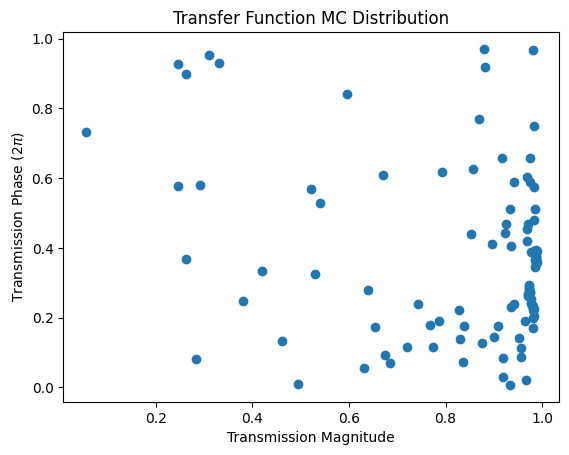

In [8]:
# Here we select out the p polarization from the transmission
# which corresponds to the component of the input plane wave source.
t_complex = df["t"].apply(
    lambda x: x.amps.sel(polarization="p", f=freq0).data.squeeze()
)
angle = np.angle(t_complex) % (2 * np.pi)
magnitude = np.abs(t_complex)

plt.scatter(magnitude, angle / (2 * np.pi))
plt.xlabel("Transmission Magnitude")
plt.ylabel(r"Transmission Phase (2$\pi$)")
plt.title("Transfer Function MC Distribution")
plt.show()

In [9]:
expanded_df = df.copy()
# Select p-polarization component of transmission coefficient
expanded_df["transmission"] = expanded_df["t"].apply(
    lambda x: x.amps.sel(polarization="p").squeeze()
)
# Drop the original 't' column since we have 'transmission' now
expanded_df.drop(["t"], axis=1, inplace=True)
# Explode the transmission we have an entry for each frequency and then add the frequency
# dimension to the table
expanded_df = expanded_df.explode(["transmission"]).reset_index(drop=True)
expanded_df["freq"] = expanded_df["transmission"].apply(lambda x: float(x.f))

# Pull out the complex number from the transmission so we can take the real and
# imaginary parts that we will use in the neural network training
expanded_df["complex"] = expanded_df["transmission"].apply(lambda x: x.data)
expanded_df["real"] = expanded_df["complex"].apply(lambda x: x.real)
expanded_df["imag"] = expanded_df["complex"].apply(lambda x: x.imag)

# Drop the 'transmission' and 'complex' columns since we have all the information
# we need in the 'real' and 'imag' columns
expanded_df.drop(["transmission"], axis=1, inplace=True)
expanded_df.drop(["complex"], axis=1, inplace=True)

# Visualize the data table we will use for training where we map the major_radius,
# minor_radius, angle (of the post rotation), freq to the real and imag parts of
# the transfer function
print("Monte Carlo data for training the neural network surrogate model")
print(expanded_df)

# Turn the dataframe back into a Result so we can utilize as a pytorch dataset
expanded_results = tdd.Result()
expanded_results = expanded_results.from_dataframe(
    expanded_df, dims=list(results.dims) + ["freq"]
)

Monte Carlo data for training the neural network surrogate model
       major_radius  minor_radius       angle          freq      real  \
0          1.164626      0.824020  123.940513  2.968242e+13 -0.824104   
1          1.164626      0.824020  123.940513  2.965306e+13 -0.829082   
2          1.164626      0.824020  123.940513  2.962376e+13 -0.833748   
3          1.164626      0.824020  123.940513  2.959452e+13 -0.838101   
4          1.164626      0.824020  123.940513  2.956533e+13 -0.842145   
...             ...           ...         ...           ...       ...   
10095      1.592570      0.791313   93.300831  2.710601e+13 -0.432486   
10096      1.592570      0.791313   93.300831  2.708152e+13 -0.424745   
10097      1.592570      0.791313   93.300831  2.705708e+13 -0.416992   
10098      1.592570      0.791313   93.300831  2.703268e+13 -0.409215   
10099      1.592570      0.791313   93.300831  2.700833e+13 -0.401421   

           imag  
0     -0.068787  
1     -0.056283  
2   

We can use the `Result` class directly as a pytorch dataset and take advantage of pytorch utilities to create a training, validation, and testing split of the data. The training data is used to adjust network weights. Validation data is used to assess the quality of the model when applied to non-training data. It is a helpful evaluation criteria when deciding between different network hyperparameters. We reserve testing data for the end to perform a final verification on the trained model.

In [10]:
# Neural Network parameters
number_samples = len(expanded_results)
train_samples = int(np.floor(0.6 * number_samples))
validation_samples = int(np.floor(0.2 * number_samples))
test_samples = number_samples - train_samples - validation_samples
batch_size = 16
epochs = 100
final_training_epochs = 1000

training_dataset, validation_dataset, test_dataset = torch.utils.data.random_split(
    expanded_results, [train_samples, validation_samples, test_samples]
)

training_dataloader = DataLoader(
    training_dataset,
    batch_size=batch_size,
    shuffle=True,
)
validation_dataloader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
)
testing_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

loss_fn = nn.MSELoss()

In this section, we set up the general structure for a fully connected neural network with a variable number of hidden layers, ReLU activation functions, and the option to include dropout layers to prevent overfitting and improve generalization. The input to the network is given by three geometric parameters and the frequency, the four of which are normalized to fall between [-1, 1] based on their allowed ranges. The output of the network is the real and imaginary parts of the p-polarized output field.

In [11]:
# Assuming the features are coming in as (major_radius, minor_radius, angle, freq)
# and we can normalize by the min/max possible values to center each feature in [-1, 1]
min_freq = np.min(freqs)
max_freq = np.max(freqs)

subtract_min = torch.tensor(
    [major_radius_span[0], minor_radius_span[0], angle_deg_span[0], min_freq],
    dtype=torch.float,
)
normalize_max = torch.tensor(
    [
        major_radius_span[1] - major_radius_span[0],
        minor_radius_span[1] - minor_radius_span[0],
        angle_deg_span[1] - angle_deg_span[0],
        max_freq - min_freq,
    ],
    dtype=torch.float,
)

network_input_size = 4


# Define the model in PyTorch
class VariableANN(nn.Module):
    def __init__(self, input_size, neurons, dropout) -> None:
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, neurons[0]))

        for i in range(1, len(neurons)):
            self.layers.append(nn.Linear(neurons[i - 1], neurons[i]))

        self.layers.append(nn.Linear(neurons[-1], 2))

        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        subtract_min_unsqueeze = torch.unsqueeze(subtract_min, dim=0)
        normalize_max_unsqueeze = torch.unsqueeze(normalize_max, dim=0)

        x = x - subtract_min_unsqueeze
        x = x / normalize_max_unsqueeze
        x = 2.0 * (x - 0.5)

        for layer in self.layers[:-1]:
            x = self.drop(self.relu(layer(x)))

        x = self.layers[-1](x)

        return x

We set up functions here to facilitate the training of the neural network. By default, we use an MSE loss function in the training that computes the mean squared error between the network's predicted real and imaginary parts of the field and the ground truth complex field's real and imaginary parts. In each epoch of training, we run through all the batches in the training dataset, adjusting the weights in the network with an Adam optimizer after each batch. We also keep track of the validation loss from when the network is in evaluation mode and processing data from the validation dataset. This will be useful later for choosing the best network hyperparameters.

In [12]:
loss_fn = nn.MSELoss()


def evaluate_loss(data, network, loss_fn_user=None):
    """Extract inputs/labels from the data and allow for loss evaluation on user defined loss
    function (otherwise use the default loss_fn which is set to MSE)."""

    inputs, labels = data

    if loss_fn_user is None:
        loss_fn_user = loss_fn

    loss = loss_fn_user(
        network(inputs.type(torch.FloatTensor)), labels.type(torch.FloatTensor)
    )

    return loss


def evaluate_loss_from_loader(data_loader, network, loss_fn_user=None):
    """Given a data_loader, run all the batches through the network and evaluate loss."""
    loss_by_iteration = []
    for data_idx, data in enumerate(data_loader):
        loss = evaluate_loss(data, network, loss_fn_user)
        loss_by_iteration.append(loss.item())

    avg_loss = np.mean(loss_by_iteration)
    return avg_loss


def train_network(hyperparameters, epochs):
    """Train a network according to hyperparameters specification for a given number of epochs."""

    # Build network and set to training mode
    network = VariableANN(
        network_input_size, hyperparameters["hidden"], hyperparameters["dropout"]
    )
    network.train()
    opt = optim.Adam(
        network.parameters(),
        lr=hyperparameters["learning_rate"],
        weight_decay=hyperparameters["weight_decay"],
    )

    training_loss_by_epoch = np.zeros(1 + epochs)
    validation_loss_by_epoch = np.zeros(1 + epochs)

    avg_training_loss = evaluate_loss_from_loader(training_dataloader, network)
    avg_validation_loss = evaluate_loss_from_loader(validation_dataloader, network)

    training_loss_by_epoch[0] = avg_training_loss
    validation_loss_by_epoch[0] = avg_validation_loss

    final_training_loss = np.inf
    final_validation_loss = np.inf
    for epoch_idx in range(0, epochs):
        training_loss_by_iteration = []

        for data_idx, data in enumerate(training_dataloader):
            opt.zero_grad()
            loss = evaluate_loss(data, network)

            training_loss_by_iteration.append(loss.item())

            loss.backward()
            opt.step()

        # Remove training freatures like dropout for the evaluation section and then turn it back on for training
        network.eval()
        avg_validation_loss = evaluate_loss_from_loader(validation_dataloader, network)
        network.train()

        training_loss_by_epoch[1 + epoch_idx] = np.mean(training_loss_by_iteration)
        validation_loss_by_epoch[1 + epoch_idx] = avg_validation_loss

    return training_loss_by_epoch, validation_loss_by_epoch, network

Next, we perform a random search over the network and optimizer hyperparameters to find the best network structure and optimization configuration. The figure of merit for the search is the validation error for the trained model because we ultimately care both about good network performance and the ability to generalize outside the training set. This search is done by randomly sampling hidden layer dimensions, number of hidden layers, and dropout percentage for the network and the learning rate and weight decay for the Adam optimizer. In this search, we fix the network to two hidden layers and train 75 trial network and optimization parameter combinations searching for the best validation loss. The tidy3d design plugin once again is useful here as we can utilize the Monte Carlo method once again to randomly choose parameters to evaluate.

In [13]:
allowed_hidden_layer_sizes = np.arange(16, 257, 16)
allowed_dropout = np.arange(0, 0.55, 0.05)
num_hidden_layers = 2
allowed_learning_rate_log_range = (-5, -3)
allowed_weight_decay_log_range = (-5, -4)

num_trial_networks = 75


def hyperparemeter_fn(
    dropout, learning_rate_log, weight_decay_log, **hidden_layer_sizes
):
    hidden_layer_sizes = [
        hidden_layer_sizes[f"hidden_layer_size_{idx}"]
        for idx in range(0, len(hidden_layer_sizes))
    ]

    hyperparam = {
        "hidden": hidden_layer_sizes,
        "dropout": dropout,
        "learning_rate": 10**learning_rate_log,
        "weight_decay": 10**weight_decay_log,
    }

    training_loss, validation_loss, network = train_network(hyperparam, epochs)

    return -validation_loss[-1]


param_dropout = tdd.ParameterAny(name="dropout", allowed_values=tuple(allowed_dropout))
param_lr_log = tdd.ParameterFloat(
    name="learning_rate_log", span=allowed_learning_rate_log_range
)
param_wd_log = tdd.ParameterFloat(
    name="weight_decay_log", span=allowed_weight_decay_log_range
)
params_hyperparameter = [
    tdd.ParameterAny(
        name=f"hidden_layer_size_{idx}",
        allowed_values=tuple(allowed_hidden_layer_sizes),
    )
    for idx in range(0, num_hidden_layers)
]

hyperparameters = [param_dropout, param_lr_log, param_wd_log] + params_hyperparameter

hyperparam_optimizer = tdd.MethodMonteCarlo(
    num_points=num_trial_networks,
    seed=2,
)
design_space = tdd.DesignSpace(
    method=hyperparam_optimizer,
    parameters=hyperparameters,
    task_name="Metalens_Network_MC",
    path_dir=str(mc_data_dir),
)
network_hyperparameter_results = design_space.run(hyperparemeter_fn, verbose=True)

After the hyperparameter search, we perform one final network training using the best hyperparameter settings and an increased number of training epochs. This network can now operate as the surrogate solver for the elliptical post unit cells. We note that in the training/validation curves below that the validation loss is sometimes better than the training loss in cases where we have a nonzero dropout percentage. This is due to the validation loss being evaluated without the dropout layers in place, which happens when the network is switched from training mode to evaluation mode. Since the dropout randomly cuts connections in the network, it leads to lower performance as seen in the training loss. However, it improves generalization and thus practical performance of the network.

Best network hyperparameters:
hidden : [144, 160]
dropout : 0.0
learning_rate : 0.0005177283857996054
weight_decay : 1.4211205011036916e-05

Average training loss: 0.001725776641817621
Average validation loss: 0.0020784560946644996
Average test loss: 0.001936384644011021
Average L1 validation loss: 0.02964838503265944
Average L1 test loss: 0.02875120226499133


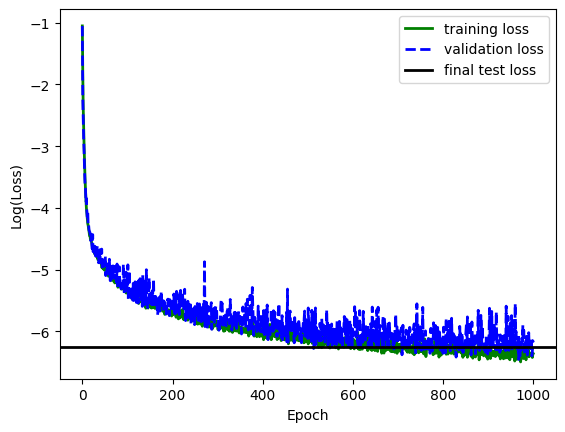

In [14]:
# Extract the best parameters from the design space result and formulate the hyperparameter dictionary for the optimziation
best_parameters = dict(
    zip(
        network_hyperparameter_results.dims,
        network_hyperparameter_results.coords[
            np.argmax(network_hyperparameter_results.values)
        ],
    )
)
best_hyperparam = {
    "hidden": [
        best_parameters[f"hidden_layer_size_{idx}"]
        for idx in range(0, num_hidden_layers)
    ],
    "dropout": best_parameters["dropout"],
    "learning_rate": 10 ** best_parameters["learning_rate_log"],
    "weight_decay": 10 ** best_parameters["weight_decay_log"],
}
print("Best network hyperparameters:")
for k, v in best_hyperparam.items():
    print(f"{k} : {v}")
avg_training_loss, avg_validation_loss, optimized_network = train_network(
    best_hyperparam, final_training_epochs
)
optimized_network.eval()

# Report the final average training loss from the final optimization as well as the validation and test losses for eval mode
avg_test_loss = evaluate_loss_from_loader(testing_dataloader, optimized_network)
print(f"\nAverage training loss: {avg_training_loss[-1]}")
print(f"Average validation loss: {avg_validation_loss[-1]}")
print(f"Average test loss: {avg_test_loss}")

# Compute the L1 validation and test loss in eval mode to get a better intuitive sense of the network performance by examining
# absolute error instead of squared error
l1_loss_fn = nn.L1Loss()
avg_l1_validation_loss = evaluate_loss_from_loader(
    validation_dataloader, optimized_network, l1_loss_fn
)
avg_l1_test_loss = evaluate_loss_from_loader(
    testing_dataloader, optimized_network, l1_loss_fn
)

print(f"Average L1 validation loss: {avg_l1_validation_loss}")
print(f"Average L1 test loss: {avg_l1_test_loss}")

# Plot log of loss curves for the network
plt.plot(
    np.arange(0, len(avg_training_loss)),
    np.log(avg_training_loss),
    color="g",
    linewidth=2,
    label="training loss",
)
plt.plot(
    np.arange(0, len(avg_validation_loss)),
    np.log(avg_validation_loss),
    color="b",
    linewidth=2,
    label="validation loss",
    linestyle="--",
)
plt.axhline(y=np.log(avg_test_loss), color="k", linewidth=2, label="final test loss")
plt.xlabel("Epoch")
plt.ylabel("Log(Loss)")
plt.legend()
plt.show()

## Unit Cell Library Optimization

Using the surrogate model we trained in the previous step, we can now build a metasurface library by searching for the correct cylindrical post radius for each desired phase value between [0, 2$\pi$]. We limit this search to a circular cross section because we will ultimately use this library to make a lens where we would like the phase imparted by the post to be independent of input polarization. First, we choose optical characteristics of the metalens (radius, numerical aperture) and convert this specification into the desired phase value at each point in the metasurface. We show this for a single quadrant because of the problem symmetry. The phase profile is taken from an ideal phase profile (see https://www.flexcompute.com/tidy3d/examples/notebooks/MidIRMetalens/).

The number of unit cells is 7396.
The diameter of the metalens is 1.060 mm. The focal length is 0.707 mm.


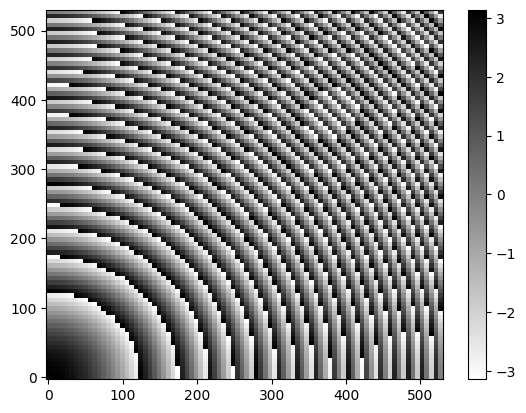

In [15]:
R = 50 * lda0  # radius of the designed metalens

# define a grid of cells
r = np.arange(0, R, P)
print(f"The number of unit cells is {len(r)**2}.")
X, Y = np.meshgrid(r, r)

NA = 0.6  # numerical aperture of the designed metalens

f = R / NA * np.sqrt(1 - NA**2)  # focal length
print(
    f"The diameter of the metalens is {2*R/1e3:.3f} mm. The focal length is {f/1e3:.3f} mm."
)

# Desired phase profile
phi_map = (2 * np.pi * (f - np.sqrt(X**2 + Y**2 + f**2)) / lda0) % (-2 * np.pi) + np.pi

# Plot the desired phase profile
plt.pcolormesh(X, Y, phi_map, cmap="binary")
plt.colorbar()
plt.show()

Now, we set up a way to interface with the surrogate solver in the post optimization routine. We create a function, `make_prediction`, that converts geometric parameters and frequency into the output real and imaginary parts of the field by running them through the surrogate solver.

In [16]:
def make_prediction(network, major_radius, minor_radius, angle, freq):
    """Use the surrogate network to predict the complex value of the output
    field based on the unit cell geometric parameters."""
    feature_array = np.expand_dims(
        np.array([major_radius, minor_radius, angle, freq]), axis=0
    )
    input_tensor = torch.Tensor(feature_array)
    prediction = np.squeeze(network(input_tensor).detach().numpy())

    return prediction

In this section, we compute a metasurface lookup table based on the surrogate solver. For cylindrical posts, we plot the expected transmission phase and magnitude as a function of radius. A good metasurface library will have $2\pi$ phase coverage for ideally unit transmission. Here, we are testing if the surrogate model predicts a full library rather than running each of these post sizes through the solver. In the next section, we will tile this library of posts to achieve the required phase function for a lens. Note here that the surrogate solver sometimes predicts transmission values that are greater than 1. In the current model, there is nothing enforcing physical constraints on the network's output. This is a challenge with data driven solver surrogates and can be improved by using different model architectures and making the network respect these physical constraints.

The predicted transmittance also looks unexpected for a transmissive post library. This may be due to the fact that the network is learning based on 

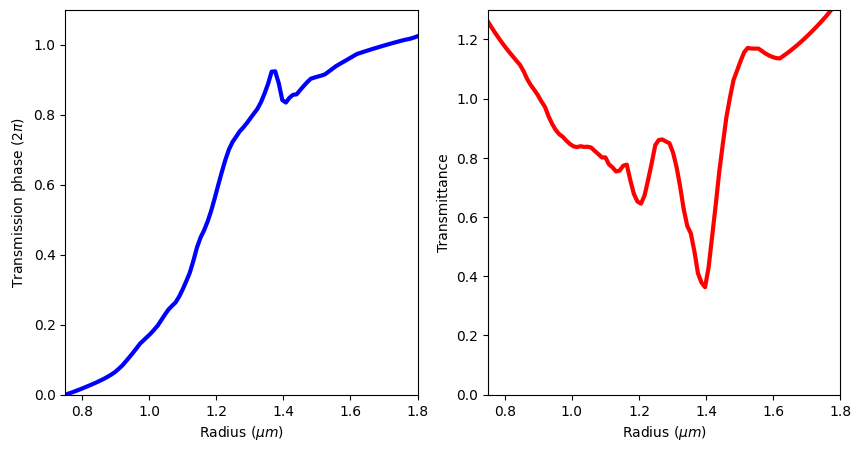

In [17]:
# Plot test for cylinders
radius_values = np.linspace(major_radius_span[0], major_radius_span[1], 100)

complex_vals = []
for radius in radius_values:
    feature_array = np.array((radius, radius, 0, freq0))
    prediction = make_prediction(optimized_network, *feature_array)
    comp_num = prediction[0] + prediction[1] * 1j
    complex_vals.append(comp_num)

complex_arr = np.array(complex_vals)
post_theta = np.unwrap(np.angle(complex_arr))
post_theta = post_theta - post_theta[0]
post_magnitude = np.abs(complex_arr)

# Plot the transmission phase
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(radius_values, post_theta / (2 * np.pi), linewidth=3, c="blue")
ax1.set_xlim(np.min(radius_values), np.max(radius_values))
ax1.set_ylim(0, 1.1)
ax1.set_xlabel(r"Radius ($\mu m$)")
ax1.set_ylabel(r"Transmission phase ($2\pi$)")

# Plot the transmittance
ax2.plot(radius_values, post_magnitude, linewidth=3, c="red")
ax2.set_xlim(np.min(radius_values), np.max(radius_values))
ax2.set_ylim(0, 1.3)
ax2.set_xlabel(r"Radius ($\mu m$)")
ax2.set_ylabel("Transmittance")
plt.show()

From the desired grid of transmission phase in `phi_range`, we choose the post radius that most closely achieves the desired phase at each point in the array. Here, these phases are those predicted via the surrogate model above when we swept the post radius and recorded the phase and amplitude. We define a phase function that is maximized for high transmission and a closely matched phase value. The use of `cos` ensures that the phase can differ from the target phase by a multiple of 2$\pi$.

In [18]:
# Phi grid we are considering for tiling on metasurface
phi_range = np.linspace(phi_map.min(), phi_map.max(), num_phi_optimization_points)
# Radius values to achieve each target phi
radius_for_phi = np.zeros(num_phi_optimization_points)

for phi_idx, target_phi in enumerate(phi_range):
    # Merit function is maximal for high transmission and a phase that matches the target
    # while allowing the phases to differ by multiples of 2pi
    merit_function = post_magnitude * np.cos(post_theta - target_phi)
    radius_for_phi[phi_idx] = radius_values[np.argmax(merit_function)]

# Create pillar geometries at each cell to follow the desired phase profile
ellipse_structures = []
for i, x in enumerate(r):
    for j, y in enumerate(r):
        if x**2 + y**2 <= R**2 and x >= 0 and y >= 0:
            best_phi_location = np.argmin(np.abs(phi_map[i][j] - phi_range))
            post_radius = radius_for_phi[best_phi_location]
            post_rotation_angle_deg = 0
            ellipse = create_ellipse(
                post_radius, post_radius, post_rotation_angle_deg, x, y
            )
            ellipse_structures.append(ellipse)

Now, we can set up a simulation of the full metalens geometry and analyze its focusing performance by running a tidy3d simulation.

In [19]:
# Simulation domain size
Lx = 2 * R + lda0
Ly = 2 * R + lda0
Lz = h + 1.3 * lda0

# Grids of the projected field position
xs_far = np.linspace(-3 * lda0, 3 * lda0, 101)
ys_far = np.linspace(-3 * lda0, 3 * lda0, 101)

# Define a field projection monitor
monitor_proj = td.FieldProjectionCartesianMonitor(
    center=[0, 0, h + 0.6 * lda0],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="focal_plane_proj",
    proj_axis=2,
    proj_distance=f,
    x=xs_far,
    y=ys_far,
    custom_origin=(0, 0, 0),
    far_field_approx=False,
)

# Define geometry
substrate_geo = td.Box.from_bounds(
    rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, 0)
)
substrate = td.Structure(geometry=substrate_geo, medium=caf2, name="substrate")

# Add a plane wave source
plane_wave1 = td.PlaneWave(
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
    size=(td.inf, td.inf, 0),
    center=(0, 0, -0.1 * lda0),
    direction="+",
    pol_angle=0,  # polarization along x-direction
)

min_steps_per_wvl = 12

# Define the simulation
metalens_sim = td.Simulation(
    center=(0, 0, Lz / 2 - lda0 / 2),
    size=(Lx, Ly, Lz),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl, wavelength=lda0),
    structures=ellipse_structures + [substrate],
    sources=[plane_wave1],
    monitors=[monitor_proj],
    run_time=sim_run_time,
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml()
    ),
    symmetry=(-1, 1, 0),
)

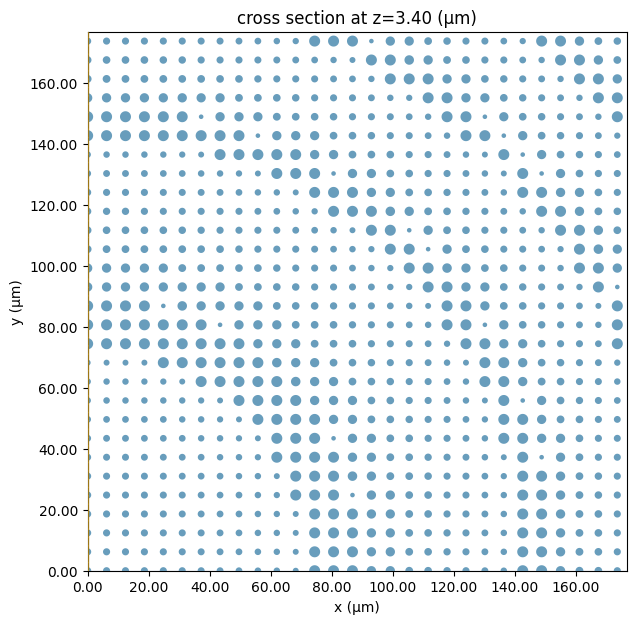

In [20]:
# Visualize the optimized cross section of the metasurface
fig, ax = plt.subplots(figsize=(7, 7))
metalens_sim.plot(z=h / 2, ax=ax)
ax.set_xlim(0, R / 3)
ax.set_ylim(0, R / 3)
plt.show()

In [21]:
# Since this is a big simulation file, we first check the maximum cost of the job
job = web.Job(simulation=metalens_sim, task_name="ir_metalens")
estimated_cost = web.estimate_cost(job.task_id)

20:56:13 CST Created task 'ir_metalens' with task_id                            
             'fdve-7da66b52-106a-4caa-9221-766c99b85e94' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=86290;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7da66b52-106a-4caa-9221-766c99b85e94\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=230423;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7da66b52-106a-4caa-9221-766c99b85e94\taskId]8;;\]8;id=86290;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7da66b52-106a-4caa-9221-766c99b85e94\=]8;;\]8;id=504708;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7da66b52-106a-4caa-9221-766c99b85e94\fdve]8;;\]8;id=86290;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7da66b52-106a-4caa-9221-766c99b85e94\-7da66b52-106]8;;\
             ]8;id=86290;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7da66b52-106a-4caa-9221-766c99b85e94\a-4caa-9221-766c99b85e94']8;;\.

Output()

20:57:03 CST Maximum FlexCredit cost: 12.734. Minimum cost depends on task      
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

20:57:34 CST Maximum FlexCredit cost: 12.734. Minimum cost depends on task      
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

In [22]:
# Run the metasurface simulation
sim_data = web.run(metalens_sim, task_name="metalens_full_sim")

             Created task 'metalens_full_sim' with task_id                      
             'fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=301564;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=572125;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\taskId]8;;\]8;id=301564;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\=]8;;\]8;id=258565;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\fdve]8;;\]8;id=301564;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\-a7a33db4-d4f]8;;\
             ]8;id=301564;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\a-4dee-8fc1-2693959aa9b1']8;;\.

Output()

20:58:10 CST Maximum FlexCredit cost: 12.734. Minimum cost depends on task      
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

20:58:20 CST status = queued

...

Output()

21:00:35 CST status = success

21:00:36 CST View simulation result at                                          
             ]8;id=221086;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=766005;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\taskId]8;;\]8;id=221086;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\=]8;;\]8;id=478593;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\fdve]8;;\]8;id=221086;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\-a7a33db4-d4f]8;;\
             ]8;id=221086;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a7a33db4-d4fa-4dee-8fc1-2693959aa9b1\a-4dee-8fc1-2693959aa9b1']8;;\.

Output()

21:00:41 CST loading simulation from simulation_data.hdf5

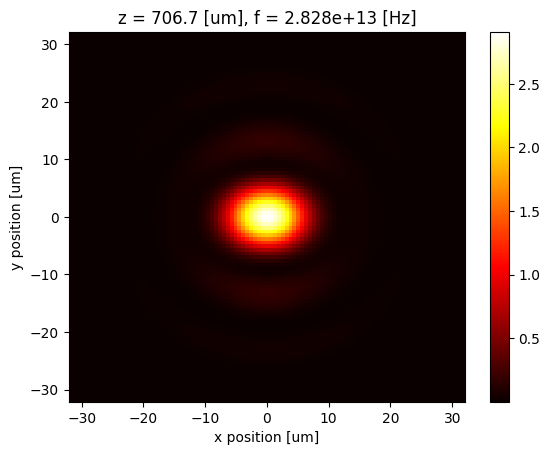

In [23]:
# Get the fields at the optimized central frequency, freq0
proj_fields = sim_data["focal_plane_proj"].fields_cartesian.sel(f=freq0)

# Compute the intensity of the field
I = (
    np.abs(proj_fields.Ex) ** 2
    + np.abs(proj_fields.Ey) ** 2
    + np.abs(proj_fields.Ez) ** 2
)

# Plot field distribution
I.plot(x="x", y="y", cmap="hot")
plt.show()

Below we plot the results of running a full field electromagnetic solve on the metasurface and propagating the near fields to the focal plane. While the metasurface posts were made to impart symmetric phase for both x- and y-polarized inputs, the choice of polarization used in the simulation leads to an asymmetric focal shape as can be seen in the intensity image of the focal spot as well as the line cuts through it. The reason for this is the difference in efficiency of outcoupling s- and p-polarized light from the substrate at higher angles. For x-polarized input, wavefront angles leaving the edges of the lens along the x-axis are s-polarized where the polarization lies in a plane normal to the interface. Along the y-axis, the situation is flipped and the x-polarized wavefront is p-polarized where the polarization lies in the plane of the interface. At higher angles, the Fresnel coefficients for transmission from a higher refractive index medium to a lower one (i.e. - substrate to vacuum) are higher for p-polarization than s-polarization as the angle increases and moves towards the Brewster angle (where the p-polarized transmission is 1). Since the higher angles are more efficiently coupled out when angled in the y-direction versus the x-direction, we end up with an effective higher numerical aperture along the y-axis compared to the x-axis. This can be seen in the plots below where the focal spot is narrower when looking in the x=0 cut versus the y=0 cut.

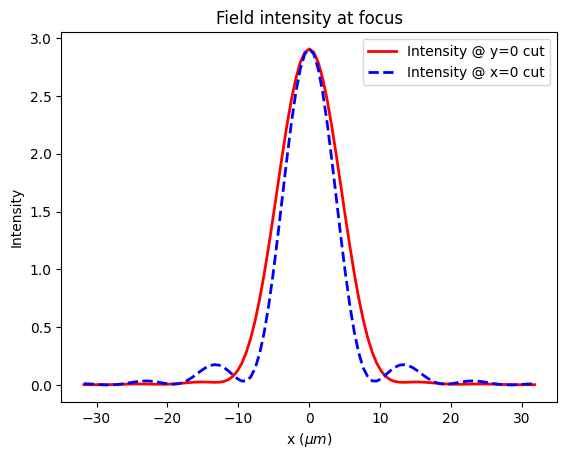

Max intensity: 2.9067839625292464
The FWHM along x-direction is 11.448 um and along y-direction is 8.904. Wavelength was 10.6 um.


In [24]:
I_x = I.sel(
    y=0, z=f, method="nearest"
)  # extract the field intensity in the x direction
I_y = I.sel(
    x=0, z=f, method="nearest"
)  # extract the field intensity in the y direction

# Plot the intensity profile
fig, ax = plt.subplots()
I_x.plot(linewidth=2, c="red", ax=ax, label="Intensity @ y=0 cut")
I_y.plot(linewidth=2, c="blue", ax=ax, linestyle="--", label="Intensity @ x=0 cut")
ax.set_ylabel("Intensity")
ax.set_xlabel(r"x ($\mu m$)")
ax.set_title("Field intensity at focus")
plt.legend()
plt.show()


# Function for determining the fwhm
def cal_fwhm(x, y):
    # filter the data
    y = y[x > 0]
    x = x[x > 0]
    x = x[y > 0.4 * np.max(y)]
    y = y[y > 0.4 * np.max(y)]

    # Compute half width by interpolation
    hm_point = np.interp(np.max(y) / 2, y, x)

    # Compute full width
    fwhm_value = 2 * hm_point

    return fwhm_value


# Calculate fwhm
fwhm_x = cal_fwhm(I_x.x.values, I_x.values)
fwhm_y = cal_fwhm(I_y.y.values, I_y.values)
print(f"Max intensity: {I_x.max().data}")
print(
    f"The FWHM along x-direction is {fwhm_x:.3f} um and along y-direction is {fwhm_y:.3f}. Wavelength was {lda0} um."
)